# Lab 1 — Complex Baseband, IQ Sampling and the SDR Receive Chain

**Companion to Chapter 2** (*Signals, Spectra and Systems*: the complex envelope)
**and Chapter 7** (*The Radio Transceiver and the Software-Defined Radio*).
**Time needed:** about 60 minutes. **Difficulty:** introductory.

Every radio you will ever build throws the carrier away as early as it can and
does all the thinking on a pair of low-rate signals, I and Q. This lab makes
that trick concrete, then walks down the receive chain of a real SDR (the Ettus
B200 and its AD9364 transceiver) to see what each stage does to your signal.

### What you will learn
1. Move a signal between real passband and complex baseband, and explain why a
   baseband spectrum can be asymmetric (and why that needs *two* ADCs).
2. Predict where a tone lands after complex sampling (wrapping, not folding).
3. Extract one channel from a wideband capture with a digital down-converter (DDC).
4. Recognise the fingerprints of a direct-conversion receiver in a spectrum
   (DC offset, IQ-imbalance images, LO phase noise), and remove the IQ image blindly.
5. Relate ADC resolution, noise figure and bandwidth to dynamic range and sensitivity.

### Prerequisites
Complex exponentials, the Fourier transform and the idea of a PSD (Chapter 2).
Python with NumPy/Matplotlib at the level of "I can read a list comprehension".

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Passband and complex baseband | |
| 2 | Why two ADCs: real vs complex sampling | yes |
| 3 | Complex sampling wraps frequencies | |
| 4 | The digital down-converter | |
| 5 | Direct-conversion impairments and blind IQ correction | yes |
| 6 | LO phase noise | |
| 7 | Dynamic range: ADC bits, noise figure, sensitivity | yes |
| 8 | Working with real captures | |

**How to use this notebook.** Run it top to bottom (*Kernel → Restart & Run All*).
Sections marked *Interactive* have live controls. Each **Try it yourself** box ends
with a `lk.check(...)` line that prints PASS or FAIL for your answer.

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=1, lab="01")

Lab 01 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 1


## 1. Passband and complex baseband

Any real bandpass signal centred on a carrier $f_c$ can be written as

$$x(t) = \mathrm{Re}\{\tilde{x}(t)\,e^{j2\pi f_c t}\} = x_I(t)\cos 2\pi f_c t - x_Q(t)\sin 2\pi f_c t .$$

The **complex envelope** $\tilde{x} = x_I + j x_Q$ carries all of the information,
and it only needs a sample rate set by the signal's *bandwidth*, not by the carrier.
A 20 MHz Wi-Fi channel at 5.8 GHz needs about 20 MS/s of complex samples, not 12 GS/s.

The receiver recovers $\tilde{x}$ by mixing with $e^{-j2\pi f_c t}$ (two real mixers
driven by cosine and minus-sine) and low-pass filtering away the copy at $-2f_c$.
Below: a baseband signal with tones at **+100 Hz** and **−250 Hz**, up-converted to a
4 kHz "carrier" and brought back down.

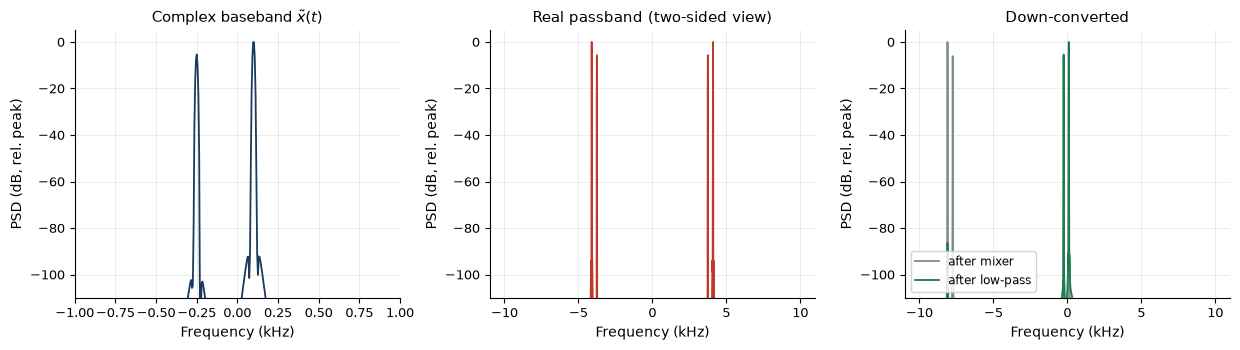

In [3]:
fs_rf, fc = 20_000, 4_000                   # simulation rate and carrier (Hz)
t = np.arange(0, 0.5, 1 / fs_rf)
xb = np.exp(2j * np.pi * 100 * t) + 0.5 * np.exp(-2j * np.pi * 250 * t)   # complex baseband
xp = np.real(xb * np.exp(2j * np.pi * fc * t))                            # real passband

lpf = firwin(201, 1_000, fs=fs_rf)                                        # removes the -2fc copy
mixed = 2 * xp * np.exp(-2j * np.pi * fc * t)                             # factor 2 restores amplitude
xr = lfilter(lpf, 1, mixed)

f, ax = lk.fig("row3", 1, 3)
lk.psd(ax[0], xb, fs_rf, 4096, scale=1e3, unit="kHz"); ax[0].set_title("Complex baseband $\\tilde{x}(t)$")
ax[0].set_xlim(-1, 1)
lk.psd(ax[1], xp.astype(complex), fs_rf, 4096, scale=1e3, unit="kHz", color=lk.RED)
ax[1].set_title("Real passband (two-sided view)")
lk.psd(ax[2], mixed, fs_rf, 4096, scale=1e3, unit="kHz", color=lk.GRAY, label="after mixer")
lk.psd(ax[2], xr, fs_rf, 4096, scale=1e3, unit="kHz", color=lk.GREEN, label="after low-pass")
ax[2].set_title("Down-converted"); ax[2].legend(loc="lower left")
for a in ax:
    a.set_ylim(-110, 5)
lk.show(f)

**What you should see.** Left: two lines at +0.1 and −0.25 kHz, *different* heights, so
the baseband spectrum is not symmetric. Middle: the real passband signal has a
Hermitian-symmetric spectrum; the information appears twice, around $+f_c$ and $-f_c$.
Right: after the mixer (grey) the wanted copy sits at 0 and an unwanted copy at
$-2f_c = -8$ kHz; the low-pass filter (green) removes it and we are back where we started.

## 2. Why two ADCs: real versus complex sampling

Suppose the receiver kept only the I branch, $x_I(t) = \mathrm{Re}\{\tilde{x}(t)\}$. A real
signal must have a symmetric spectrum, so the tones at $+f_1$ and $-f_2$ both show up at
$\pm f_1$ and $\pm f_2$: the receiver can no longer tell a signal 100 Hz *above* the
carrier from one 100 Hz *below* it. That is the image problem of a zero-IF receiver
with only one ADC. The Q branch resolves the sign of frequency.

### Interactive: where do the tones land?
Move the two tone frequencies. Watch the I-only spectrum collide when $f_2 = -f_1$.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

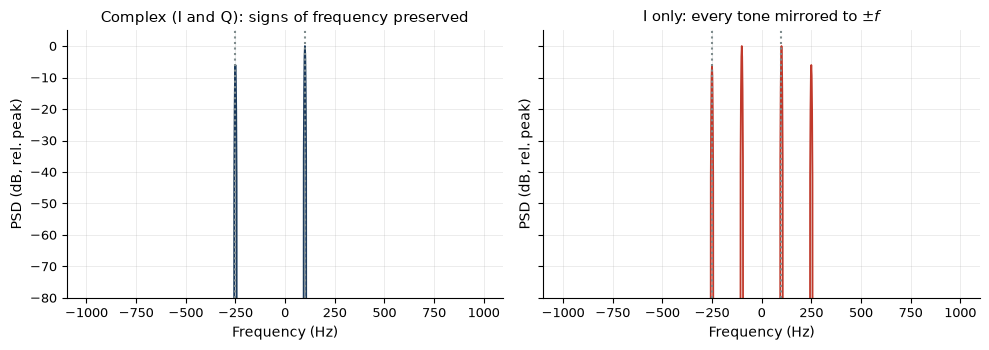

In [6]:
def real_vs_complex(f1_hz=100.0, f2_hz=-250.0, a2=0.5):
    tt = np.arange(0, 0.5, 1 / 2000)
    z = np.exp(2j * np.pi * f1_hz * tt) + a2 * np.exp(2j * np.pi * f2_hz * tt)
    f, ax = lk.fig("row2", 1, 2, sharey=True)
    lk.psd(ax[0], z, 2000, 2048, label="I + jQ")
    ax[0].set_title("Complex (I and Q): signs of frequency preserved")
    lk.psd(ax[1], z.real.astype(complex), 2000, 2048, color=lk.RED)
    ax[1].set_title("I only: every tone mirrored to $\\pm f$")
    for a in ax:
        a.set_ylim(-80, 5); a.axvline(f1_hz, color=lk.GRAY, ls=":"); a.axvline(f2_hz, color=lk.GRAY, ls=":")
    lk.show(f)

lk.interact(real_vs_complex, f1_hz=lk.slider(100, -900, 900, 10, "tone 1 (Hz)"),
            f2_hz=lk.slider(-250, -900, 900, 10, "tone 2 (Hz)"),
            a2=lk.slider(0.5, 0, 1, 0.05, "tone 2 amplitude"))

**What you should see.** With I and Q (left) there are exactly two lines. With I only
(right) there are four, and a tone at $-250$ Hz is indistinguishable from one at
$+250$ Hz. Set tone 2 to $-100$ Hz: on the right the two tones fall on top of each other
and would interfere; on the left they remain separate.

## 3. Complex sampling wraps frequencies

With complex sampling at rate $f_s$ the unambiguous band is $[-f_s/2,\ f_s/2)$, and a
tone at $f$ appears at

$$f_{\text{alias}} = \big((f + f_s/2) \bmod f_s\big) - f_s/2 .$$

Unlike real sampling there is no mirror folding, only wrapping. On the B200, tuned to
915 MHz at 1 MS/s, a signal at 915.7 MHz that slips past the anti-alias filter appears
at −300 kHz, right on top of whatever is really there.

In [9]:
def alias(f, fs):
    """Apparent frequency of a tone at f after complex sampling at fs."""
    return ((f + fs / 2) % fs) - fs / 2

fs = 1e6
rows = [(f / 1e3, alias(f, fs) / 1e3) for f in [100e3, 450e3, 700e3, -600e3, 1.3e6, 2.05e6]]
lk.table(rows, ["true offset (kHz)", "appears at (kHz)"], title="Complex sampling at fs = 1 MS/s", fmt=".0f")

true offset (kHz),appears at (kHz)
100,100
450,450
700,-300
-600,400
1300,300
2050,50


### Try it yourself 3.1
The B200 is tuned to 2.412 GHz and sampling at 5 MS/s complex. A strong interferer sits
at 2.4195 GHz and the anti-alias filter is (badly) set to 10 MHz. At what baseband
frequency (kHz) does the interferer appear? Write your answer below.

In [11]:
answer_3_1 = None          # e.g. answer_3_1 = 1234.0   (kHz)
lk.check("3.1 alias of 2.4195 GHz at 5 MS/s", answer_3_1, alias(7.5e6, 5e6) / 1e3, atol=1,
         hint="offset = 7.5 MHz; wrap it into [-2.5, 2.5) MHz")

[TODO] 3.1 alias of 2.4195 GHz at 5 MS/s: not attempted yet: replace the None with your answer

## 4. The digital down-converter (DDC)

A modern SDR samples a wide slice of spectrum and does the final channel selection in
digital hardware (the FPGA of a USRP, or your CPU). A DDC is three steps:

1. **Mix** with a numerically controlled oscillator $e^{-j2\pi f_0 n/f_s}$ so the wanted
   channel moves to 0 Hz;
2. **Low-pass filter** to reject everything else;
3. **Decimate** by $D$: keep every $D$-th sample (safe because the filter removed the
   content that would alias).

Our "capture" is 8 MS/s wide and contains a 500 kBd QPSK signal at −2 MHz, an
unmodulated carrier at +1.5 MHz and a narrowband FM-like signal at +3 MHz. We extract
the QPSK signal to 1 MS/s (decimation by 8) and look at its constellation.
Chapter 6 and Lab 17 show how to make this efficient with polyphase and CIC filters.

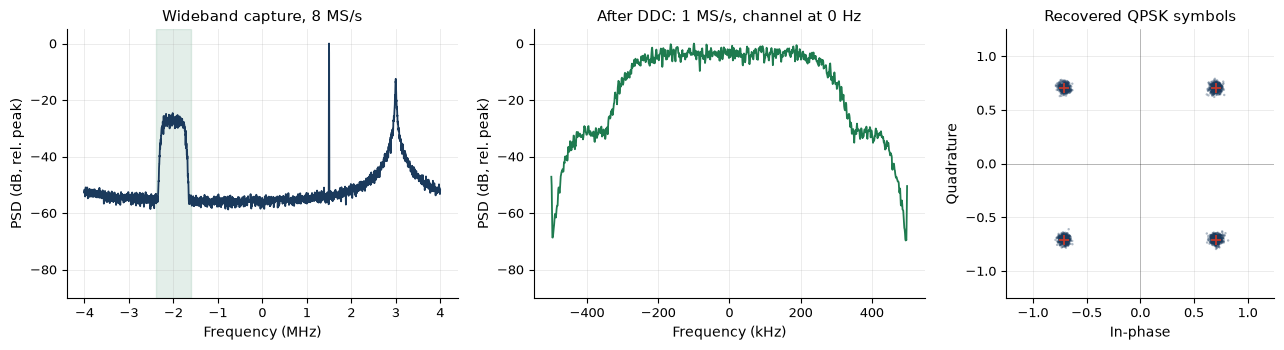

quantity,dB
QPSK SNR per 8 MS/s sample,17.9
Es/N0 (theory),30.0
-EVM after DDC + matched filter,28.3


In [13]:
fs_w, D = 8e6, 8
sps_w = int(fs_w / 500e3)                                 # 16 samples/symbol at 8 MS/s
qpsk = cl.get_constellation("qpsk")
sym = qpsk.modulate(cl.random_bits(2 * 3000, rng))
h_tx = cl.rrc_taps(0.35, sps_w, 10)
bb = cl.shape(sym, h_tx, sps_w)
n = np.arange(len(bb))
capture = (bb * np.exp(2j * np.pi * -2e6 / fs_w * n)                        # wanted QPSK
           + 0.5 * np.exp(2j * np.pi * 1.5e6 / fs_w * n)                    # carrier
           + 0.3 * np.exp(2j * np.pi * (3e6 / fs_w * n + 0.02 * np.cumsum(rng.standard_normal(len(n))))))
sigma2 = 1e-3                                             # noise variance per 8 MS/s sample
capture = capture + np.sqrt(sigma2 / 2) * (rng.standard_normal(len(n)) + 1j * rng.standard_normal(len(n)))
snr_sample = lk.db(np.mean(np.abs(bb) ** 2) / sigma2)    # QPSK power / noise, per wideband sample
esn0 = lk.db(1.0 / sigma2)                               # unit-energy pulses: Es = 1

# --- the DDC -------------------------------------------------------------------------
nco = np.exp(-2j * np.pi * -2e6 / fs_w * n)               # 1. mix -2 MHz down to 0 Hz
h_lpf = firwin(257, 450e3, fs=fs_w)                       # 2. low-pass (delay 128 = 16 x D)
y = np.convolve(capture * nco, h_lpf)[::D]                # 3. decimate by 8 -> 1 MS/s
# --- matched filter and symbol sampling (Lab 3 and Lab 4 explain these steps) --------
h_rx = cl.rrc_taps(0.35, 2, 10)
z = cl.matched_filter(y, h_rx)
cands = [z[k::2][50:2500] for k in range(2)]
z_sym = max(cands, key=lambda c: np.mean(np.abs(c) ** 2))
# data-aided gain/phase (cheating a little: Lab 4 does this blind)
lag = np.argmax([np.abs(np.vdot(sym[50 + d:2500 + d][:len(z_sym)], z_sym)) for d in range(-20, 20)]) - 20
ref = sym[50 + lag:50 + lag + len(z_sym)]
z_sym = z_sym * np.vdot(z_sym, ref) / np.vdot(z_sym, z_sym)

f, ax = lk.fig((13, 3.6), 1, 3, gridspec_kw={"width_ratios": [1.4, 1.4, 1]})
lk.psd(ax[0], capture, fs_w, 4096, scale=1e6, unit="MHz"); ax[0].set_title("Wideband capture, 8 MS/s")
ax[0].axvspan(-2.4, -1.6, color=lk.GREEN, alpha=0.12)
lk.psd(ax[1], y, fs_w / D, 1024, scale=1e3, unit="kHz", color=lk.GREEN)
ax[1].set_title("After DDC: 1 MS/s, channel at 0 Hz")
lk.constellation(ax[2], z_sym, qpsk.points, "Recovered QPSK symbols")
for a in ax[:2]:
    a.set_ylim(-90, 5)
lk.show(f)
evm = lk.db(np.mean(np.abs(z_sym - ref) ** 2))
lk.table([["QPSK SNR per 8 MS/s sample", snr_sample], ["Es/N0 (theory)", esn0],
          ["-EVM after DDC + matched filter", -evm]], ["quantity", "dB"], fmt=".1f")

**What you should see.** Three signals in the 8 MHz capture (left); after the DDC only
the QPSK channel remains, now centred on 0 Hz in a 1 MHz band (middle); the
constellation is four tight clusters (right). Per wideband sample the QPSK signal is
only about 18 dB above the noise, yet the recovered symbols have an EVM within about
2 dB of $-E_s/N_0 = -30$ dB. The ideal improvement, $10\log_{10}(16) = 12$ dB, is
**processing gain**: the DDC and matched filter throw away the noise outside the
signal's bandwidth. The last dB or two is implementation loss from our short filters.

## 5. Direct-conversion impairments: DC offset and IQ imbalance

The AD9364 in the B200 is a zero-IF transceiver, and two artefacts follow directly:

* **LO leakage / DC offset** puts a spur at 0 Hz. UHD corrects it automatically, but a
  residual always remains, so SDR designers often tune a few hundred kHz away from the
  signal of interest.
* **IQ gain/phase mismatch**: if the Q branch has gain $g$ and a phase error $\phi$, the
  output is $y = \mu x + \nu x^*$ with $\mu = (1 + g e^{j\phi})/2$ and
  $\nu = (1 - g e^{-j\phi})/2$. The conjugate term is a mirror **image** at $-f$ and the
  image-rejection ratio is $\mathrm{IRR} = |\mu|^2/|\nu|^2$.

### Interactive: impairments in the spectrum
For a 0.5 dB / 3° mismatch the IRR is about 30 dB; calibrated transceivers reach 40–60 dB.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

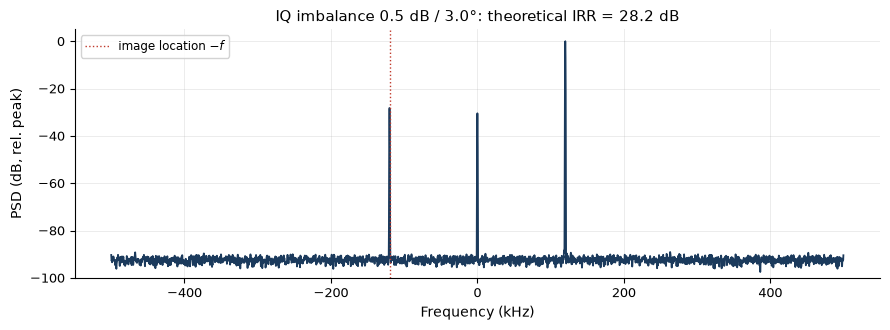

In [16]:
N = 1 << 15
nn = np.arange(N)

def irr_db(gain_db, phase_deg):
    g, phi = 10 ** (gain_db / 20), np.deg2rad(phase_deg)
    mu, nu = (1 + g * np.exp(1j * phi)) / 2, (1 - g * np.exp(-1j * phi)) / 2
    return 10 * np.log10(abs(mu) ** 2 / max(abs(nu) ** 2, 1e-15))

def impairments(tone_khz=120.0, gain_db=0.5, phase_deg=3.0, dc=0.02):
    x = np.exp(2j * np.pi * tone_khz * 1e3 / fs * nn)
    y = cl.awgn(cl.iq_imbalance(x, gain_db, phase_deg) + dc * (1 + 1j), 60, rng)
    f, ax = lk.fig("wide")
    lk.psd(ax, y, fs, 4096, scale=1e3, unit="kHz")
    ax.axvline(-tone_khz, color=lk.RED, ls=":", lw=1, label="image location $-f$")
    ax.set_title(f"IQ imbalance {gain_db} dB / {phase_deg}°: theoretical IRR = {irr_db(gain_db, phase_deg):.1f} dB")
    ax.set_ylim(-100, 5); ax.legend(loc="upper left")
    lk.show(f)

lk.interact(impairments, tone_khz=lk.slider(120, -450, 450, 10, "tone (kHz)"),
            gain_db=lk.slider(0.5, 0, 3, 0.1, "gain mismatch (dB)"),
            phase_deg=lk.slider(3, 0, 15, 0.5, "phase error (deg)"),
            dc=lk.slider(0.02, 0, 0.3, 0.01, "DC offset"))

**What you should see.** The wanted tone, a DC spur at 0 Hz, and an image at exactly
$-f$ whose height below the tone equals the IRR in the title.

### Blind IQ correction
For a *proper* (circularly symmetric) signal, I and Q have equal power and are
uncorrelated. Our impairment breaks both properties, so measuring the three moments
$E[I^2]$, $E[Q^2]$ and $E[IQ]$ tells us the gain and phase error:

$$\hat g = \sqrt{E[Q^2]/E[I^2]},\qquad \sin\hat\phi = \frac{E[IQ]}{\hat g\,E[I^2]},\qquad
Q_{\text{corr}} = \frac{Q/\hat g - \sin\hat\phi\, I}{\cos\hat\phi}.$$

This is (a simplified version of) what the AD9364's background calibration does.

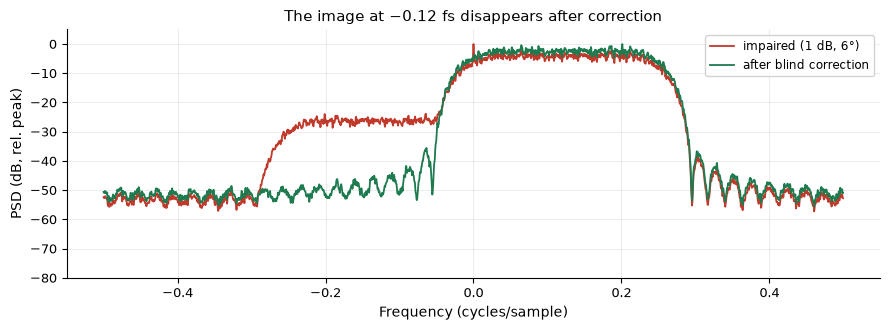

parameter,true,estimated
gain (dB),1.000,0.975
phase (deg),6.000,5.997


In [18]:
def iq_correct(y):
    """Moment-based blind IQ-imbalance correction (DC must be removed first)."""
    y = y - np.mean(y)
    i, q = y.real, y.imag
    g = np.sqrt(np.mean(q ** 2) / np.mean(i ** 2))
    s = np.mean(i * q) / (g * np.mean(i ** 2))
    return i + 1j * (q / g - s * i) / np.sqrt(1 - s ** 2), g, np.rad2deg(np.arcsin(s))

# a wideband QPSK signal (not a single tone: the estimator needs a proper signal)
sig = cl.shape(qpsk.modulate(cl.random_bits(2 * 8000, rng)), cl.rrc_taps(0.35, 4, 10), 4)
sig = sig * np.exp(2j * np.pi * 0.12 * np.arange(len(sig)))        # offset to +0.12 fs
imp = cl.awgn(cl.iq_imbalance(sig, 1.0, 6.0) + 0.05, 45, rng)
fixed, g_hat, ph_hat = iq_correct(imp)
f, ax = lk.fig("wide")
lk.psd(ax, imp, 1.0, 2048, label="impaired (1 dB, 6°)", color=lk.RED)
lk.psd(ax, fixed, 1.0, 2048, label="after blind correction", color=lk.GREEN)
ax.set_ylim(-80, 5); ax.legend(); ax.set_title("The image at −0.12 fs disappears after correction")
lk.show(f)
lk.table([["gain (dB)", 1.0, 20 * np.log10(g_hat)], ["phase (deg)", 6.0, ph_hat]],
         ["parameter", "true", "estimated"], fmt=".3f")

### Try it yourself 5.1
Using the IRR formula (or the `irr_db` helper), what image rejection in dB does a
receiver with 1 dB gain mismatch and 5° phase error achieve?

In [20]:
answer_5_1 = None          # dB
lk.check("5.1 IRR for 1 dB / 5 deg", answer_5_1, irr_db(1.0, 5.0), atol=0.3,
         hint="IRR = |mu|^2/|nu|^2 with g = 10^(1/20), phi = 5 deg")

[TODO] 5.1 IRR for 1 dB / 5 deg: not attempted yet: replace the None with your answer

## 6. LO phase noise

A real oscillator's phase wanders randomly: $e^{j\theta(t)}$ where $\theta$ is roughly a
random walk (Wiener process). In the spectrum a pure tone grows "skirts"; on a
constellation the points smear *along arcs*, and the outer points of a dense QAM
suffer most because the same angle is a longer arc at larger radius. This is why
mmWave NR adds phase-tracking reference signals (PT-RS) and why 4096-QAM needs an
excellent synthesizer.

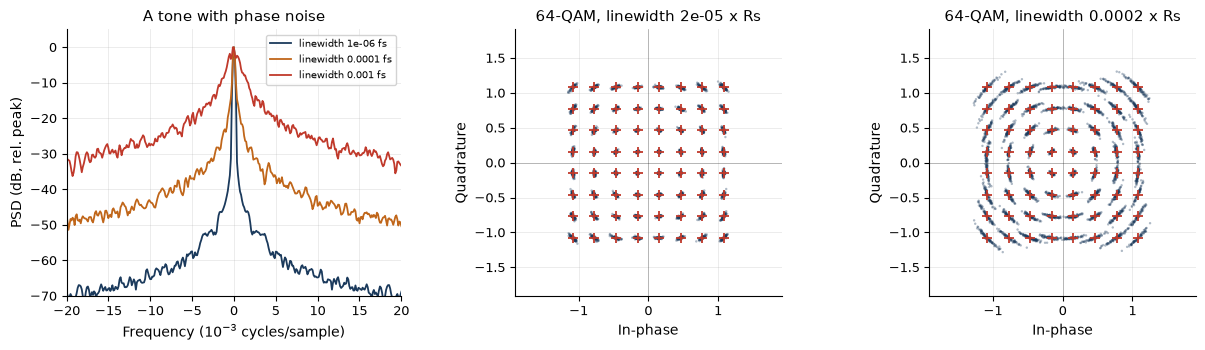

In [22]:
c64 = cl.get_constellation("64qam")
s64 = c64.modulate(cl.random_bits(6 * 6000, rng))

def tracked_phase_noise(n, linewidth, loop_len=64):
    """Wiener phase noise minus what a carrier-tracking loop (modelled as a moving
    average over loop_len symbols) removes: the residual jitter the detector sees."""
    th = np.cumsum(rng.standard_normal(n) * np.sqrt(2 * np.pi * linewidth))
    return np.exp(1j * (th - np.convolve(th, np.ones(loop_len) / loop_len, mode="same")))

f, ax = lk.fig("row3", 1, 3)
tone = np.ones(1 << 16, complex)
for lw, col in [(1e-6, lk.NAVY), (1e-4, lk.ORANGE), (1e-3, lk.RED)]:
    lk.psd(ax[0], tone * cl.phase_noise(len(tone), lw, rng), 1.0, 8192, scale=1e-3,
           unit="$10^{-3}$ cycles/sample", label=f"linewidth {lw:g} fs", color=col)
ax[0].set_xlim(-20, 20); ax[0].set_ylim(-70, 5); ax[0].legend(fontsize=7.5)
ax[0].set_title("A tone with phase noise")
for a, lw in [(ax[1], 2e-5), (ax[2], 2e-4)]:
    lk.constellation(a, cl.awgn(s64 * tracked_phase_noise(len(s64), lw), 38, rng), c64.points,
                     f"64-QAM, linewidth {lw:g} x Rs")
lk.show(f)

**What you should see.** Wider linewidth, wider skirts (left). Even after a tracking loop
has removed the slow phase wander, the fast residual jitter stretches the clusters
*tangentially*, far more at the corners than near the centre (right).

## 7. Dynamic range: ADC bits, noise figure and sensitivity

An ideal $b$-bit ADC driven by a full-scale sine achieves
$\mathrm{SQNR} \approx 6.02\,b + 1.76$ dB: about 74 dB for the B200's 12-bit converters.
Decimating to a bandwidth $B$ adds processing gain $10\log_{10}(f_s/2B)$. The analog noise
floor is $-174 + 10\log_{10}B + \mathrm{NF}$ dBm, and the receiver gain should put the
thermal noise a few LSBs above the quantization floor without clipping strong signals.

In [25]:
def quantize(x, bits, full_scale=1.0):
    """Mid-rise uniform quantizer applied separately to I and Q, with clipping."""
    q = 2 * full_scale / 2 ** bits
    clip = lambda v: np.clip(v, -full_scale, full_scale - q)
    return q * (np.floor(clip(x.real) / q) + 0.5) + 1j * q * (np.floor(clip(x.imag) / q) + 0.5)

xq = 0.999 * np.exp(2j * np.pi * 0.01234 * np.arange(1 << 16))
rows = []
for b in [4, 6, 8, 10, 12, 14, 16]:
    e = quantize(xq, b) - xq
    rows.append([b, lk.db(np.mean(np.abs(xq) ** 2) / np.mean(np.abs(e) ** 2)), 6.02 * b + 1.76])
lk.table(rows, ["bits", "measured SQNR (dB)", "6.02b + 1.76 (dB)"], fmt={1: ".1f", 2: ".1f"},
         title="Quantization noise of a full-scale complex tone")

bits,measured SQNR (dB),6.02b + 1.76 (dB)
4,25.4,25.8
6,37.7,37.9
8,49.9,49.9
10,62.0,62.0
12,74.0,74.0
14,86.1,86.0
16,98.1,98.1


### Try it yourself 7.1
Your B200 samples at 16 MS/s with 12 bits and you decimate to a 200 kHz channel.
Ignoring thermal noise, what is the SQNR in dB in the channel? (Use
$6.02b + 1.76 + 10\log_{10}(f_s/B)$ for complex sampling.)

In [27]:
answer_7_1 = None          # dB
lk.check("7.1 SQNR after decimation", answer_7_1, 6.02 * 12 + 1.76 + 10 * np.log10(16e6 / 200e3), atol=0.5)

[TODO] 7.1 SQNR after decimation: not attempted yet: replace the None with your answer

### Interactive: receiver noise floor, sensitivity and range
Sensitivity is $P_{\min} = -174 + 10\log_{10}B + \mathrm{NF} + \mathrm{SNR}_{\text{req}}$ dBm.
The B200 datasheet quotes a noise figure below 8 dB. The range estimate assumes free space
and 0 dBi antennas: optimistic, because it has no fading margin (Chapter 11).

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

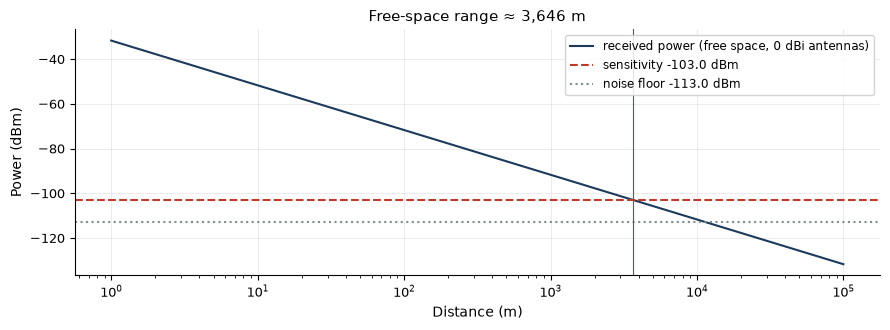

In [29]:
def sensitivity(bw_khz=200.0, nf_db=8.0, snr_req_db=10.0, fc_mhz=915.0, ptx_dbm=0.0):
    floor = -174 + 10 * np.log10(bw_khz * 1e3) + nf_db
    pmin = floor + snr_req_db
    d = np.logspace(0, 5, 300)
    prx = ptx_dbm - cl.fspl_db(d, fc_mhz * 1e6)
    dmax = d[np.argmin(np.abs(prx - pmin))]
    f, ax = lk.fig("wide")
    ax.semilogx(d, prx, label="received power (free space, 0 dBi antennas)")
    ax.axhline(pmin, color=lk.RED, ls="--", label=f"sensitivity {pmin:.1f} dBm")
    ax.axhline(floor, color=lk.GRAY, ls=":", label=f"noise floor {floor:.1f} dBm")
    ax.axvline(dmax, color=lk.GREEN, lw=0.8)
    ax.set_xlabel("Distance (m)"); ax.set_ylabel("Power (dBm)"); ax.legend(loc="upper right")
    ax.set_title(f"Free-space range ≈ {dmax:,.0f} m")
    lk.show(f)

lk.interact(sensitivity, bw_khz=lk.slider(200, 10, 20000, 10, "bandwidth (kHz)"),
            nf_db=lk.slider(8, 1, 15, 0.5, "noise figure (dB)"),
            snr_req_db=lk.slider(10, 0, 30, 1, "required SNR (dB)"),
            fc_mhz=lk.slider(915, 70, 6000, 5, "carrier (MHz)"),
            ptx_dbm=lk.slider(0, -40, 20, 1, "TX power (dBm)"))

**What you should see.** Every 10 dB of extra sensitivity (narrower bandwidth, lower NF,
lower required SNR) multiplies the free-space range by about 3.16. Doubling the carrier
frequency halves it, because the path loss with isotropic antennas grows as $f^2$.

## 8. Working with real captures

`gnuradio/gr01_spectrum_iq_capture.py` writes raw `complex64` samples (GNU Radio's
`.cfile` convention) plus a SigMF metadata file. The cell below loads
`../data/capture.cfile` if it exists; otherwise it synthesises a stand-in so the
notebook always runs.

No capture found: using a synthetic stand-in. Record one with
  python gnuradio/gr01_spectrum_iq_capture.py --out ../data/capture.cfile


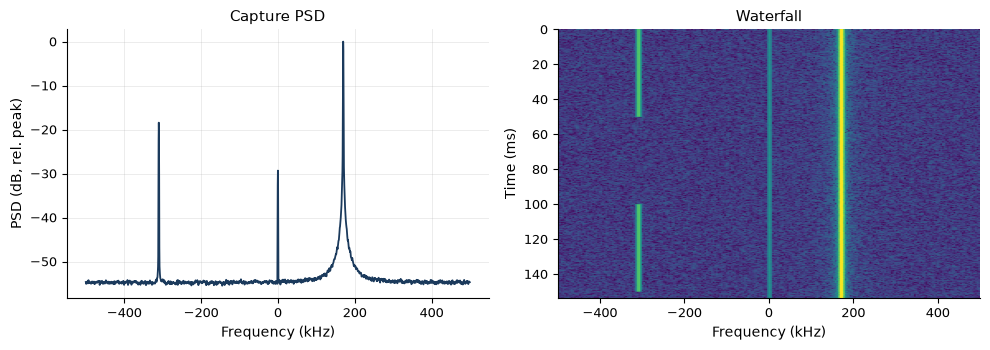

In [32]:
path = os.path.join("..", "data", "capture.cfile")
fs_cap = 1e6
if os.path.exists(path):
    iq = cl.read_cfile(path, count=2_000_000)
    print(f"Loaded {len(iq):,} samples from {path}")
else:
    tt = np.arange(400_000)
    iq = (0.3 * np.exp(2j * np.pi * (0.17 * tt + 2e-3 * np.cumsum(rng.standard_normal(len(tt)))))
          + 0.05 * np.exp(2j * np.pi * -0.31 * tt) * (tt % 100_000 < 50_000))
    iq = cl.awgn(iq, 25, rng) + 0.01
    print("No capture found: using a synthetic stand-in. Record one with\n"
          "  python gnuradio/gr01_spectrum_iq_capture.py --out ../data/capture.cfile")

f, ax = lk.fig("row2", 1, 2)
lk.psd(ax[0], iq, fs_cap, 2048, scale=1e3, unit="kHz"); ax[0].set_title("Capture PSD")
nfft, rows_ = 256, 600
spec = np.abs(np.fft.fftshift(np.fft.fft(iq[:nfft * rows_].reshape(rows_, nfft) * np.hanning(nfft), axis=1),
                              axes=1)) ** 2
ax[1].imshow(lk.db(spec), aspect="auto", cmap="viridis", vmin=np.percentile(lk.db(spec), 5),
             extent=[-fs_cap / 2e3, fs_cap / 2e3, rows_ * nfft / fs_cap * 1e3, 0])
ax[1].grid(False); ax[1].set_xlabel("Frequency (kHz)"); ax[1].set_ylabel("Time (ms)"); ax[1].set_title("Waterfall")
lk.show(f)

## Key takeaways
* The complex envelope $x_I + jx_Q$ holds all the information of a bandpass signal at a
  rate set by bandwidth. Negative frequencies are real: they are what the Q branch buys.
* Complex sampling wraps out-of-band signals into $[-f_s/2, f_s/2)$; the analog
  anti-alias filter is your only defence.
* A DDC (mix, filter, decimate) selects a channel digitally and yields processing gain.
* Zero-IF receivers leave fingerprints: a DC spur and IQ images at $-f$. Both can be
  estimated and removed blindly using the statistics of proper signals.
* Sensitivity $= -174 + 10\log B + \mathrm{NF} + \mathrm{SNR}_{\text{req}}$ dBm. Learn this
  line by heart; you will use it in every link budget in the book.

## Going further (hardware: USRP B200 / GNU Radio)
* Run `gnuradio/gr01_spectrum_iq_capture.py --freq 100e6 --rate 2e6 --out ../data/capture.cfile`
  on the FM band, then re-run Section 8 of this notebook on your own capture.
* Tune exactly onto a strong FM station, then 300 kHz away: watch the DC spur move
  relative to the signal. Toggle UHD's DC-offset and IQ-balance correction
  (`set_auto_dc_offset`, `set_auto_iq_balance`) and measure the image with Section 5.
* Chapter 7 describes the AD9364 signal chain block by block; Lab 15 simulates a full
  superheterodyne receiver and compares it with zero-IF.

## Exercises
1. **(Warm-up)** Show analytically that $\mathrm{IRR} = |\mu|^2/|\nu|^2$ for the model in
   `cl.iq_imbalance`, and that for small errors $\mathrm{IRR} \approx 4/(\epsilon^2 + \phi^2)$
   where $\epsilon = g - 1$.
2. **(Core)** The blind corrector in Section 5 fails on a single tone. Explain why
   (hint: is a complex tone a proper signal over a short window?) and verify it.
3. **(Core)** Capture 2 s of the FM broadcast band at 100 MHz with gr01 at 2 MS/s.
   Identify the stations and estimate each one's occupied bandwidth (99% power).
4. **(Core)** Replace the 129-tap FIR in the DDC with a 3-stage CIC decimator followed by
   a short compensation FIR (see Lab 17) and compare the stop-band rejection.
5. **(Stretch)** Sweep the B200 RX gain from 0 to 76 dB while receiving a weak signal.
   Plot measured SNR against gain and identify where the noise-figure improvement
   stops and where compression begins.

In [34]:
lk.summary()

[good] Lab 01 finished in 2.4 s. Self-checks: 0 passed, 0 failed, 3 still to do.